____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, drifters_sources, assign_attrs, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# 15m

In [5]:
DAK = []
AK = ['swot2kmnaive']
for alti_key in AK:  
    f = sorted(glob(os.path.join(zarr_dir, 'save','10days_time_to_swot', f'save_savedeltaT_10days_{alti_key}*_15m_filtered.nc')))
    DAK.append(xr.open_mfdataset(f))


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_71269/2148056039.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))


In [41]:
#DSS = xr.concat(D, pd.Index(AK, name = 'alti_key'))


KeyboardInterrupt



In [30]:
DAK[0]

<xarray.Dataset> Size: 3GB
Dimensions:          (id_comb: 3, row_number: 2972342)
Coordinates:
    datetime         (id_comb, row_number) datetime64[ns] 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    longitude        (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    latitude         (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    pass_number      (id_comb, row_number) int64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    time_to_swot     (id_comb, row_number) timedelta64[ns] 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    cycle_number     (id_comb, row_number) int64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    drifter_id       (id_comb, row_number) <U9 321MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    drifter_type     (id_comb, row_number) <U7 250MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    depth            (id_comb, row_number) int64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    phi              (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
  * row_number       (row_number) int64 24MB 84 85 86 ... 7462215 7462216
  * id_comb          (id_comb) <U47 564B 'nofilter_LF__swot2kmnaive_etaf__rio...
Data variables: (12/31)
    sume             (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    acce             (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    exce_acc         (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    core             (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    exce_cor         (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    ggde             (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    ...               ...
    prodn_acc_ggd    (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    prodn_acc_wd     (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    prodn_cor_ggd    (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    prodn_cor_wd     (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    prodn_ggd_wd     (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>
    time_to_swot_1h  (id_comb, row_number) float64 71MB dask.array<chunksize=(1, 2972342), meta=np.ndarray>

In [28]:
dff = DAK[0].to_dataframe()
dss = compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h', compute_error = 'centrallimit')

X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}

dss['sX'] = dss[X[0]]
for x in X[1:]:
    dss['sX']= dss['sX']+dss[x]

dss['time_to_swot_1h'] = (dss.time_to_swot_1h/24).assign_attrs(long_name = 'Drifter-altimetry time gap', units='day')

In [ ]:
dss.to_netcdf(os.path.join(zarr_dir, 'save','10days_time_to_swot', 'savedeltaT_all_MS_15m_filtered.nc'))

___________
# If already computed 

In [26]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'save','10days_time_to_swot', 'savedeltaT_all_MS_15m_filtered.nc'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}


In [23]:
dss

<xarray.Dataset> Size: 260kB
Dimensions:            (time_to_swot_1h: 240, alti_key: 4, frequency_band: 3)
Coordinates:
  * time_to_swot_1h    (time_to_swot_1h) float64 2kB 0.0 0.04167 ... 9.917 9.958
  * alti_key           (alti_key) <U18 288B 'L3-2km-SWOT' ... 'L4-SWOT'
  * frequency_band     (frequency_band) <U8 96B 'LF' 'All' 'Inertial'
Data variables: (12/134)
    ACCe               (time_to_swot_1h) float64 2kB ...
    CORe               (time_to_swot_1h) float64 2kB ...
    GGDe               (time_to_swot_1h) float64 2kB ...
    WDe                (time_to_swot_1h) float64 2kB ...
    Se                 (time_to_swot_1h) float64 2kB ...
    sigmae             (time_to_swot_1h) float64 2kB ...
    ...                 ...
    ser__X_cor_ggd     (time_to_swot_1h) float64 2kB ...
    ser__X_cor_wd      (time_to_swot_1h) float64 2kB ...
    ser__X_ggd_wd      (time_to_swot_1h) float64 2kB ...
    ser__D_cyclo       (time_to_swot_1h) float64 2kB ...
    ser__D_anticyclo   (time_to_swot_1h) float64 2kB ...
    sX                 (time_to_swot_1h) float64 2kB ...

____
# Diag

In [36]:
def plot_error(df, x, v, ax, suf = 'ber__'):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color="silver"
    )
def low_filter(ds, T=2, cutoff = [0.9], vars_ = ['B_ggd', 'E_ggd']+X):
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    pass_zero = True
    # coefficients
    dt = 1/24  # 1h in days
    numtaps = int(T / dt)
    pass_zero = True
    # filter
    dss = ds.fillna(0)
    taps = signal.firwin(numtaps, cutoff=cutoff, pass_zero=pass_zero, fs=1 / dt, scale=True)
    for v in vars_ : 
        dss[v] = xr.DataArray(
            filtfilt(taps, 1, dss[v]),
            dims=[ "time_to_swot_1h"],
            )
    return dss
dsd = low_filter(dss, cutoff = 0.5)    


Text(0.5, 0.98, '15m- filtered position')

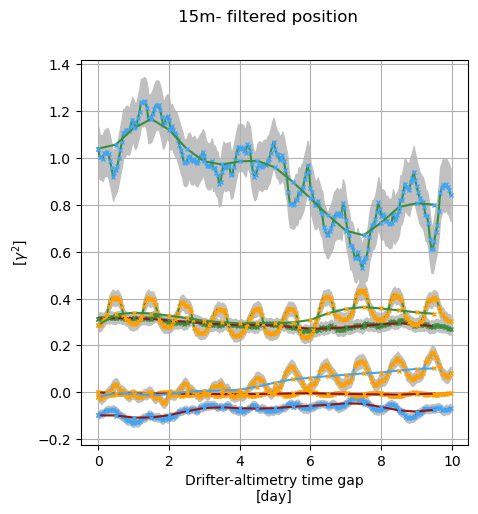

In [37]:

fig, ax = plt.subplots(1, 1, figsize=(5,5), frameon=False)
for x in X :
    dss[x].plot(label=x, **xstyle[x.replace('X_', '')], ax=ax)
    dsd.isel(time_to_swot_1h= slice(0, None, 12))[x].plot(label=x,**xstyle[x.replace('X_', '')], ax=ax)
    plot_error(dss,'time_to_swot_1h', x, ax, suf = 'ser__')

#ax.legend()

ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
fig.suptitle('15m- filtered position')


Text(0.5, 0.98, '15m')

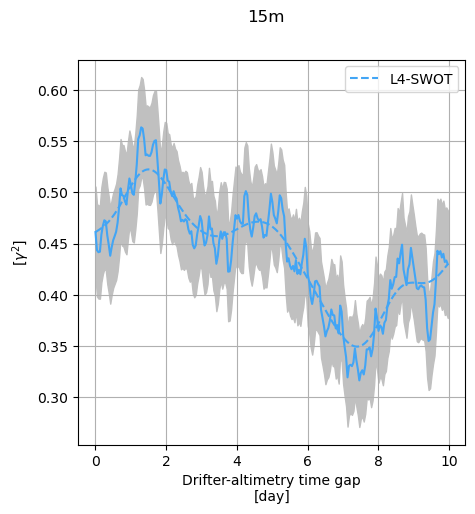

In [39]:

al_color = {'L3-250m-SWOT':'navy', 'L3-2km-SWOT':c0['ggd'],'L4-regional-noSWOT' :'b','L4-global-noSWOT':'teal', 'L4-SWOT':'lightblue'}

fig, ax = plt.subplots(1, 1, figsize=(5,5), frameon=False)#, sharey=True)

dss['B_ggd'].plot( c = al_color['L3-2km-SWOT'], ax=ax)
dsd['B_ggd'].plot( c = al_color['L3-2km-SWOT'], ls='--', ax=ax)
plot_error(dss,'time_to_swot_1h','B_'+v, ax, suf = 'ser__')
    
ax.legend()


ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
    #ax.set_xlabel('Drifter-altimetry time gap [h]')

fig.suptitle('15m')


1.2890950082486392


/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xrscipy/signal/spectral.py:308: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  f, t, Pxy = _spectral_helper(


Text(0.5, 1.0, '')

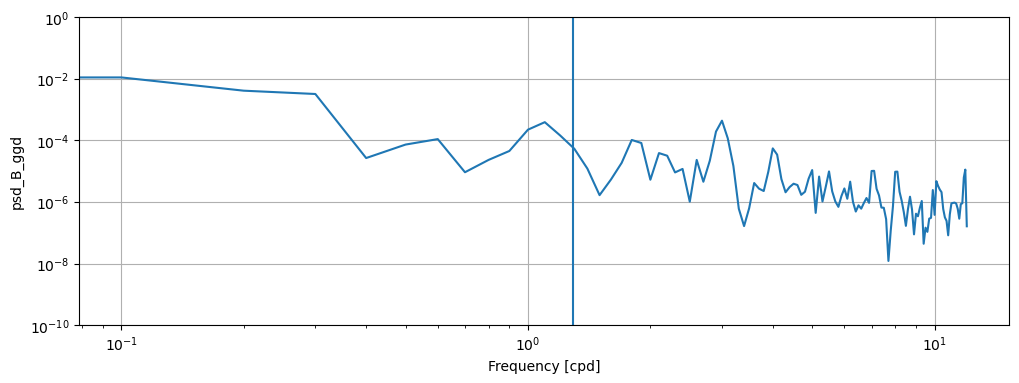

In [34]:
import xrscipy.signal.extra as dsp_extra
dsd = dsp_extra.psd(dss.B_ggd, dim="time_to_swot_1h")
fig, ax = plt.subplots(1, 1, figsize=(12, 4), frameon=False)
fc = pyn.geo.coriolis(40) * 86400 / 2 / np.pi
print(fc)
dsd.plot(ax=ax, hue='frequency_band')
ax.axvline(abs(fc))
ax.set_xlabel("Frequency [cpd]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.set_ylim(1e-10, 1e0)
#ax.set_xlim(-24 * 60 / 30 / 2, 24 * 60 / 30 / 2)
ax.set_title("")
